In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pickle
import pandas as pd
with open('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/rf_model.pkl', 'rb') as f:
  rf_model = pickle.load(f)

train_features = pd.read_pickle('/content/drive/MyDrive/Colab Notebooks/Future_ML_01/Data/train_features.pkl')

In [6]:
candidate = train_features.groupby(['store_nbr', 'family'])['sales'].agg(['sum', 'count', lambda x: (x==0).mean()])
candidate.columns = ['n_days', 'total_sales', 'zero_rate']
candidate = candidate.sort_values('total_sales', ascending = False)
print(candidate.head(10))

                                  n_days  total_sales  zero_rate
store_nbr family                                                
54        SEAFOOD                 2938.0         1684   0.394893
1         AUTOMOTIVE              5475.0         1684   0.131235
          BABY CARE                  0.0         1684   1.000000
          BEAUTY                  4056.0         1684   0.150831
          BEVERAGES            2673769.0         1684   0.003563
          BOOKS                    211.0         1684   0.924584
54        HOME AND KITCHEN II    14625.0         1684   0.308789
          HOME AND KITCHEN I     25170.0         1684   0.310570
          HARDWARE                1191.0         1684   0.553444
          GROCERY II             13406.0         1684   0.040380


(1684,)


<Axes: title={'center': 'Daily sales - store 1/BEVERAGES'}, xlabel='date'>

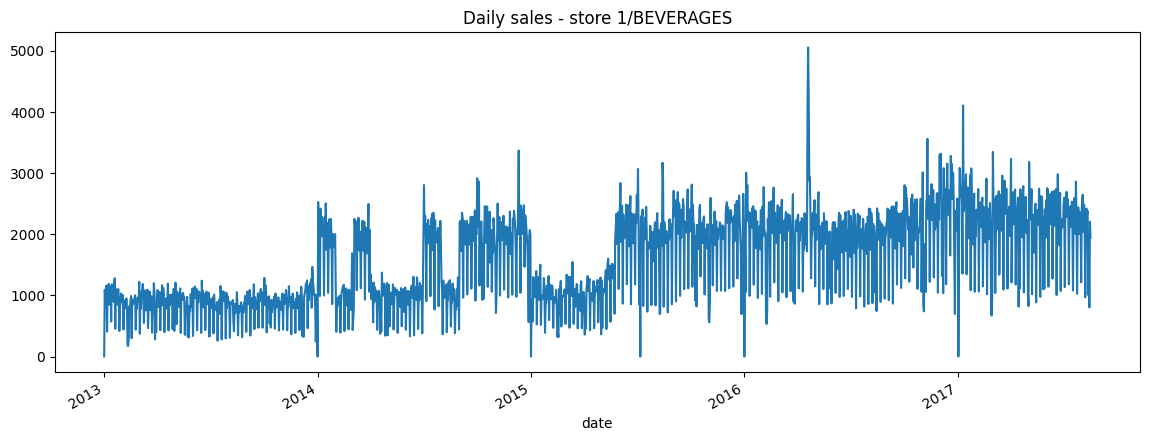

In [7]:
# as beverages from store_nbr = 1 has minimum value of zero rate means minimum sparsity

series = train_features[(train_features['store_nbr'] == 1) & (train_features['family'] == 'BEVERAGES')]
series = series.sort_values('date').set_index('date')['sales']
print(series.shape)
series.plot(figsize = (14,5), title = 'Daily sales - store 1/BEVERAGES')

<Axes: title={'center': 'Daily sales of store 1/BEVERAGES'}, xlabel='date'>

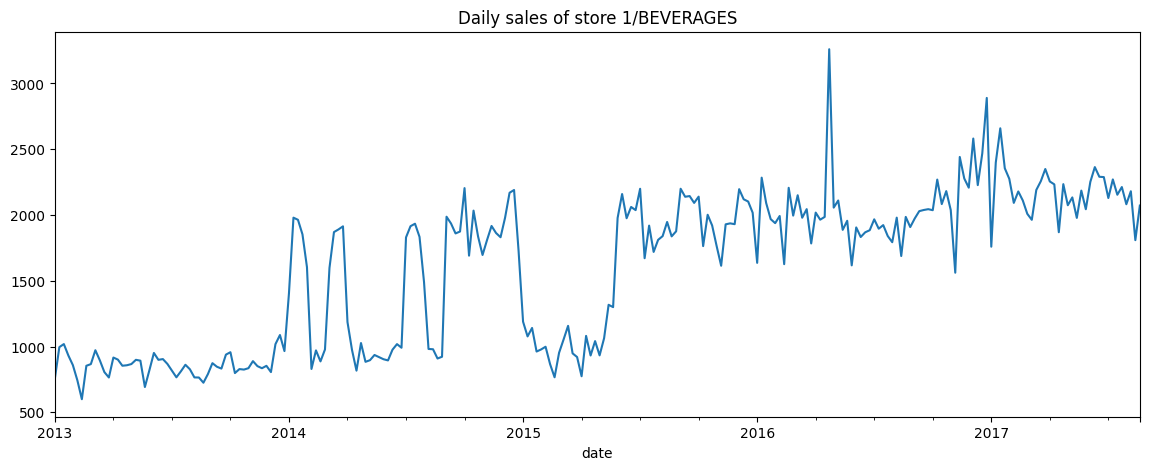

In [8]:
series.resample('W').mean().plot(figsize =(14,5), title = 'Daily sales of store 1/BEVERAGES')

In [9]:
series = series.asfreq('D')
print(series.isnull().sum())

4


In [11]:
series = series.fillna(0)
print(series.isnull().sum())

0


In [12]:
train_series = series[:-90]
test_series = series[-90:]
print (train_series.shape, test_series.shape)

(1598,) (90,)


In [14]:
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(train_series, order= (1,1,1), seasonal_order = (1,1,1,7), enforce_stationarity=False, enforce_invertibility=False)
sarima_result = model.fit(disp = False)
print(sarima_result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1598
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -11444.655
Date:                           Sun, 19 Jul 2026   AIC                          22899.310
Time:                                   14:55:18   BIC                          22926.139
Sample:                               01-01-2013   HQIC                         22909.278
                                    - 05-17-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3196      0.023     13.920      0.000       0.275       0.365
ma.L1         -0.8662      0.016    -53.360

In [22]:
forecast = sarima_result.get_forecast(steps = 90)
sarima_pred = forecast.predicted_mean
evaluate("sarima_test", test_series, sarima_pred)


sarima_test --> MAE:232.73, RMSE: 313.79, R2: 0.6655


In [20]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
def evaluate(label, y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  print(f"{label} --> MAE:{mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

As on comparing our SARIMA model is performing quite well than random forest model on a particular store product family. so SARIMA is our Best Model for now.